# Listing Weeks 2-3

In [5]:
import pandas as pd
import numpy as np

listing = pd.read_csv("../../IDX_Data/listing_combined_residential.csv")
print("Shape:", listing.shape)
listing.head()

/var/folders/hx/s9px6scd2pl5dqfp0pldbdgc0000gn/T/ipykernel_59047/683367248.py:4: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv("../../IDX_Data/listing_combined_residential.csv")


Shape: (540624, 84)


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [6]:
listing.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [7]:
listing.info()

<class 'pandas.DataFrame'>
RangeIndex: 540624 entries, 0 to 540623
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539857 non-null  float64
 1   ListingKey                    540624 non-null  int64  
 2   ListAgentEmail                493182 non-null  str    
 3   CloseDate                     161474 non-null  str    
 4   ClosePrice                    140903 non-null  float64
 5   ListAgentFirstName            536373 non-null  str    
 6   ListAgentLastName             540584 non-null  str    
 7   Latitude                      460455 non-null  float64
 8   Longitude                     460455 non-null  float64
 9   UnparsedAddress               539930 non-null  str    
 10  PropertyType                  540624 non-null  str    
 11  LivingArea                    540069 non-null  float64
 12  ListPrice                     540624 non-null  float64


In [8]:
listing['PropertyType'].unique()

<StringArray>
['Residential']
Length: 1, dtype: str

In [9]:
print("Property Types:", listing['PropertyType'].unique())

# Filter to Residential
listing = listing[listing['PropertyType'] == 'Residential']
print("Shape after Residential filter:", listing.shape)

Property Types: <StringArray>
['Residential']
Length: 1, dtype: str
Shape after Residential filter: (540624, 84)


In [10]:
null_counts = listing.isnull().sum()
null_counts.sort_values(ascending=False).head(20)

TaxAnnualAmount                 540624
FireplacesTotal                 540624
ElementarySchoolDistrict        540624
TaxYear                         540624
BusinessType                    540624
MiddleOrJuniorSchoolDistrict    540624
CoveredSpaces                   540624
AboveGradeFinishedArea          540624
BelowGradeFinishedArea          537602
CoBuyerAgentFirstName           526659
BuilderName                     515392
LotSizeDimensions               512397
BuildingAreaTotal               492510
ElementarySchool                476270
MiddleOrJuniorSchool            476140
BuyerAgencyCompensation         461631
BuyerAgencyCompensationType     461611
HighSchool                      456171
CoListAgentFirstName            420091
CoListAgentLastName             419691
dtype: int64

In [11]:
missing_pct = (listing.isnull().sum() / len(listing)) * 100
missing_df = pd.DataFrame({
    'missing_count': listing.isnull().sum(),
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

missing_df.head(20)

,missing_count,missing_pct
TaxAnnualAmount,540624,100.000000
FireplacesTotal,540624,100.000000
ElementarySchoolDistrict,540624,100.000000
TaxYear,540624,100.000000
BusinessType,540624,100.000000
MiddleOrJuniorSchoolDistrict,540624,100.000000
CoveredSpaces,540624,100.000000
AboveGradeFinishedArea,540624,100.000000
BelowGradeFinishedArea,537602,99.441016
CoBuyerAgentFirstName,526659,97.416874


In [12]:
high_missing = missing_df[missing_df['missing_pct'] > 90]
high_missing

,missing_count,missing_pct
TaxAnnualAmount,540624,100.000000
FireplacesTotal,540624,100.000000
ElementarySchoolDistrict,540624,100.000000
TaxYear,540624,100.000000
BusinessType,540624,100.000000
MiddleOrJuniorSchoolDistrict,540624,100.000000
CoveredSpaces,540624,100.000000
AboveGradeFinishedArea,540624,100.000000
BelowGradeFinishedArea,537602,99.441016
CoBuyerAgentFirstName,526659,97.416874


In [13]:
listing[['ListPrice', 'LivingArea']].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
)

,ListPrice,LivingArea
count,5.406240e+05,5.400690e+05
mean,1.314333e+06,1.979920e+03
std,2.348587e+06,2.337313e+04
min,1.000000e+02,0.000000e+00
1%,2.100000e+05,5.880000e+02
25%,5.800000e+05,1.247000e+03
50%,8.450000e+05,1.669000e+03
75%,1.375000e+06,2.300000e+03
99%,8.200000e+06,6.300000e+03
max,1.950000e+08,1.702132e+07


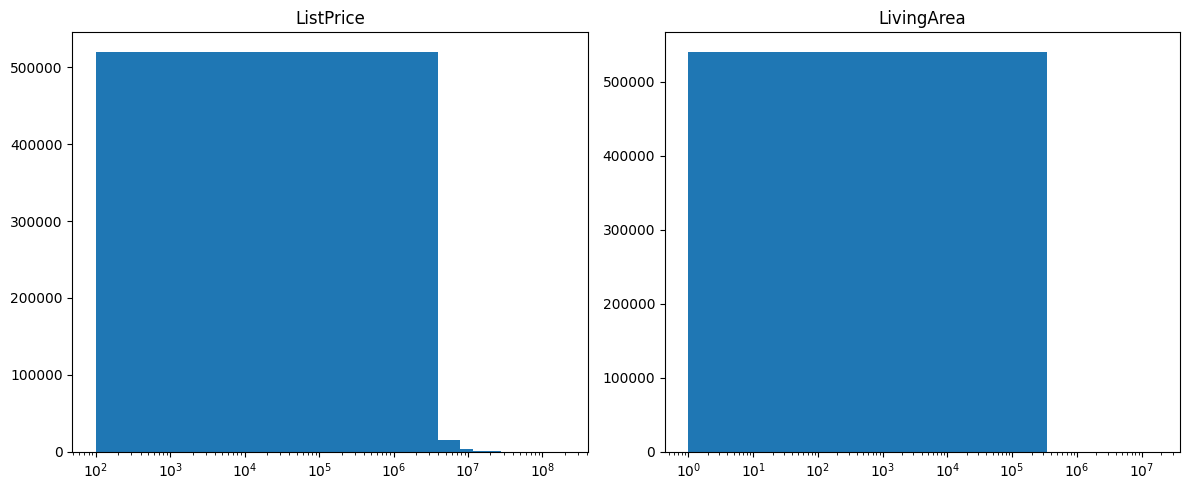

In [14]:
import matplotlib.pyplot as plt

cols = ['ListPrice', 'LivingArea']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(cols):
    data = listing[col].dropna()
    data = data[data > 0]  # safe for log
    
    axes[i].hist(data, bins=50)
    axes[i].set_title(col)
    axes[i].set_xscale('log')

plt.tight_layout()
plt.show()

In [15]:
listing.to_csv("listing_filtered_week2_3.csv", index=False)
print("Saved listing dataset.")

Saved listing dataset.
